In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import neuromaps
from neuromaps import datasets, transforms, images, resampling, nulls, stats
from scipy.stats import pearsonr, spearmanr, zscore, rankdata
from statsmodels.stats.multitest import multipletests
import math

from itertools import combinations
from neuromaps.datasets import fetch_atlas
from neuromaps.images import load_data
from neuromaps.datasets import fetch_annotation
from neuromaps import plotting
from neuromaps import datasets, images, nulls, resampling
from neuromaps.stats import compare_images
from statsmodels.stats.multitest import multipletests

In [2]:
print("neuromaps version:", neuromaps.__version__)

neuromaps version: 0.0.5+41.gf0ed67c


In [3]:
## Preprocessing brain data

brain_maps = [
    {'source': 'savli2012', 'desc': 'way100635', 'space': 'MNI152', 'res': '3mm'},
    {'source': 'margulies2016', 'desc': 'fcgradient01', 'space': 'fsLR', 'den': '32k'},
    {'source': 'raichle', 'desc': 'cmrglc', 'space': 'fsLR', 'den': '164k'},
    {'source': 'mueller2013', 'desc': 'intersubjvar', 'space': 'fsLR', 'den': '164k'},
    {'source': 'abagen', 'desc': 'genepc1', 'space': 'fsaverage', 'den': '10k'},
    {'source': 'hcps1200', 'desc': 'myelinmap', 'space': 'fsLR', 'den': '32k'},
    {'source': 'hcps1200', 'desc': 'thickness', 'space': 'fsLR', 'den': '32k'},
    {'source': 'reardon2018', 'desc': 'scalingnih', 'space': 'civet', 'den': '41k'}
]

single_sphere_counter = 0
for map in brain_maps:
    brain_map = datasets.fetch_annotation(**map)
    if len(brain_map) != 2:
        single_sphere_counter += 1
        print(map)
print(single_sphere_counter)

readable_map_names = {
    'genepc1': 'PC1 Gene Expression',
    'myelinmap': 'T1w/T2w Ratio',
    'thickness': 'Cortical Thickness',
    'fcgradient01': 'Functional Gradient',
    'intersubjvar': 'Intersubject Variability',
    'cmrglc': 'Glucose Metabolism',
    'scalingnih': 'Allometric Scaling (NIH)',
    'way100635':' 5-HT1A Receptor'
}


[References] Please cite the following papers if you are using this data:

  For {'source': 'savli2012', 'desc': 'way100635', 'space': 'MNI152', 'res': '3mm'}:
  [primary]:
    Markus Savli, Andreas Bauer, Markus Mitterhauser, Yu-Shin Ding, Andreas Hahn, Tina Kroll, Alexander Neumeister, Daniela Haeusler, Johanna Ungersboeck, Shannan Henry, and others. Normative database of the serotonergic system in healthy subjects using multi-tracer pet. Neuroimage, 63(1):447–459, 2012.
  [secondary]:
    
{'source': 'savli2012', 'desc': 'way100635', 'space': 'MNI152', 'res': '3mm'}

[References] Please cite the following papers if you are using this data:

  For {'source': 'margulies2016', 'desc': 'fcgradient01', 'space': 'fsLR', 'den': '32k'}:
  [primary]:
    Daniel S Margulies, Satrajit S Ghosh, Alexandros Goulas, Marcel Falkiewicz, Julia M Huntenburg, Georg Langs, Gleb Bezgin, Simon B Eickhoff, F Xavier Castellanos, Michael Petrides, and others. Situating the default-mode network along a princ

In [4]:
def is_volumetric(map_dict):
    """Check if a map is volumetric (MNI space)"""
    return map_dict.get('space') in ['MNI152', 'MNI305']

## Load and transform the dara
def load_and_prepare_map(map_dict, readable_map_names=None, target_space='fsLR', target_den='32k'):
    """
    Load a brain map and prepare it for analysis
    - Volumetric maps: transform to surface
    - Surface maps: resample if needed, use both hemispheres
    - return (transformed data array, space, density)
    """
    # Determine display name for logging
    desc = map_dict['desc']
    if readable_map_names and desc in readable_map_names:
        display_name = readable_map_names[desc]
    else:
        display_name = desc
    
    # Fetch the map
    brain_map = datasets.fetch_annotation(**map_dict)
    
    # Check if volumetric
    if is_volumetric(map_dict):
        print(f"Volumetric map detected, transforming to {target_space} surface...")
        
        # Transform volumetric to surface (both hemispheres)
        try:
            surface_map = transforms.mni152_to_fslr(brain_map, fslr_density=target_den)
            # surface_map will be a tuple of (left_hemi, right_hemi)
            lh_data = images.load_data(surface_map[0])
            rh_data = images.load_data(surface_map[1])
            full_data = np.hstack([lh_data, rh_data])
            return full_data, target_space, target_den
            
        except Exception as e:
            print(f"    Warning: Could not transform volumetric map: {e}")
 
    # Surface map processing
    else:
        src_space = map_dict.get('space')
        src_den = map_dict.get('den')
        template = {'source': 'hcps1200', 'desc': 'thickness', 'space': 'fsLR', 'den': '32k'}
        template_map = datasets.fetch_annotation(**template)
        # Load both hemispheres
        if len(brain_map) == 2:
            lh_map, rh_map = brain_map
        else:
            raise ValueError(f"Expected 2 hemispheres for surface map, got {len(brain_map)}")
        
        if src_den != target_den or src_space != target_space:
            print(f"Resampling from {src_space}-{src_den} to {target_space}-{target_den}...")            
            # Resample both hemispheres
            lh_resampled, _ = resampling.resample_images(
                lh_map, template_map[0],
                src_space=src_space, trg_space=target_space,
                hemi='L', resampling='transform_to_trg'
            )
            rh_resampled, _ = resampling.resample_images(
                rh_map, template_map[1],
                src_space=src_space, trg_space=target_space,
                hemi='R', resampling='transform_to_trg'
            )
            
            lh_data = images.load_data(lh_resampled)
            rh_data = images.load_data(rh_resampled)
        else:
            lh_data = images.load_data(lh_map)
            rh_data = images.load_data(rh_map)
        
        full_data = np.hstack([lh_data, rh_data])
        return full_data, src_space if src_den == target_den else target_space, \
               src_den if src_den == target_den else target_den

In [5]:
## RUN THIS 
# takes about 12 min to run

prepared_maps = []
map_names = []
nulls_list = []
n_perm = 1000

for i, b_map in enumerate(brain_maps):
    prep_data, _, _ = load_and_prepare_map(
                                            b_map, 
                                            readable_map_names=readable_map_names, 
                                            target_space='fsLR', 
                                            target_den='32k')
    prepared_maps.append(prep_data)

    name = f"{b_map['source']}_{b_map['desc']}"
    map_names.append(name)

    desc = b_map['desc']
    display_name = readable_map_names.get(desc, desc)
    
    rotated = nulls.alexander_bloch(
        prep_data, 
        atlas='fsLR', 
        density='32k', 
        n_perm=n_perm, 
        seed=1234 + i 
    )
    nulls_list.append(rotated)


[References] Please cite the following papers if you are using this data:

  For {'source': 'savli2012', 'desc': 'way100635', 'space': 'MNI152', 'res': '3mm'}:
  [primary]:
    Markus Savli, Andreas Bauer, Markus Mitterhauser, Yu-Shin Ding, Andreas Hahn, Tina Kroll, Alexander Neumeister, Daniela Haeusler, Johanna Ungersboeck, Shannan Henry, and others. Normative database of the serotonergic system in healthy subjects using multi-tracer pet. Neuroimage, 63(1):447–459, 2012.
  [secondary]:
    
Volumetric map detected, transforming to fsLR surface...

[References] Please cite the following papers if you are using this data:

  For {'source': 'margulies2016', 'desc': 'fcgradient01', 'space': 'fsLR', 'den': '32k'}:
  [primary]:
    Daniel S Margulies, Satrajit S Ghosh, Alexandros Goulas, Marcel Falkiewicz, Julia M Huntenburg, Georg Langs, Gleb Bezgin, Simon B Eickhoff, F Xavier Castellanos, Michael Petrides, and others. Situating the default-mode network along a principal gradient of macr

In [6]:
## Compute heat map correlation matrix

def compute_preliminary_matrix(prepared_maps, map_names, nulls_list, n_perm=1000, readable_map_names=None):
    """
    - prepared_maps: List of numpy arrays (N_vertices,) for each map.
    - map_names: List of strings naming each map.
    - nulls_list: List of null arrays (N_vertices, n_perm) for each map.
    - n_perm: Number of permutations used (default 1000).
    - readable_map_names: Dictionary mapping map keys (desc) to readable strings.
    """
    
    data_stack = np.column_stack(prepared_maps)
    
    # Global Mask: Remove vertices where ANY map is missing data
    global_mask = np.all((~np.isnan(data_stack)) & (data_stack != 0), axis=1)
    
    clean_data = data_stack[global_mask]
    n_vertices_clean = clean_data.shape[0]
    
    # Z-Score to standardize units (Correlation == Covariance)
    clean_data_z = zscore(clean_data, axis=0)
    
    real_corr = (clean_data_z.T @ clean_data_z) / n_vertices_clean

    p_counts = np.zeros((len(prepared_maps), len(prepared_maps)))
    
    clean_nulls_list = [n[global_mask, :] for n in nulls_list]
    
    for k in range(n_perm):
        if k % 100 == 0: print(f"Permutation {k}/{n_perm}...")
        
        null_data_k = np.zeros_like(clean_data_z)
        for m in range(len(prepared_maps)):
            spin_k = clean_nulls_list[m][:, k]
            null_data_k[:, m] = zscore(spin_k, nan_policy='omit')
            
        null_corr_k = np.corrcoef(null_data_k.T)
        
        # Check: Is random correlation stronger than real correlation?
        is_stronger = np.abs(null_corr_k) >= np.abs(real_corr)
        p_counts += is_stronger.astype(int)

    p_values = (p_counts + 1) / (n_perm + 1)
    
    # Resolve readable names for the DataFrame columns/indices
    display_names = map_names
    if readable_map_names is not None:
        display_names = []
        for name in map_names:
            if name in readable_map_names:
                display_names.append(readable_map_names[name])
                continue
            found_match = False
            for key, val in readable_map_names.items():
                if name.endswith(f"_{key}"):
                    display_names.append(val)
                    found_match = True
                    break
            
            if not found_match:
                display_names.append(name)
    
    df_corr = pd.DataFrame(real_corr, index=display_names, columns=display_names).round(3)
    df_pvals = pd.DataFrame(p_values, index=display_names, columns=display_names).round(3)
    
    # Mask non-significant values (p > 0.05)
    df_significant = df_corr.copy()
    df_significant[df_pvals > 0.05] = 0
    
    return df_corr, df_pvals, df_significant


## Function to plot heatmaps
def plot_correlation_heatmaps(df_corr, df_significant, method=None):
    """
    Plots two side-by-side heatmaps: 
    1. The Full Correlation Matrix
    2. The Significant-Only Matrix (Non-significant cells masked)
    """
    fig, axes = plt.subplots(1, 2, figsize=(20, 10))
    
    sns.heatmap(
        df_corr, 
        annot=True, 
        fmt=".2f", 
        cmap='RdBu', 
        center=0, 
        vmin=-1, vmax=1,
        square=True,
        ax=axes[0],
        cbar_kws={'label': method}
    )
    axes[0].set_title("Full Correlation Matrix", fontsize=16)
    axes[0].tick_params(axis='x', rotation=45)
    axes[0].tick_params(axis='y', rotation=0)
    
    # plot matrix masked
    mask = (df_significant == 0)
    
    sns.heatmap(
        df_significant, 
        annot=True, 
        fmt=".2f", 
        cmap='RdBu_r', 
        center=0, 
        vmin=-1, vmax=1,
        square=True,
        mask=mask, # hide non significant cells
        ax=axes[1],
        cbar_kws={'label': method}
    )
    axes[1].set_title("Significant Correlations Only (p < 0.05)", fontsize=16)
    axes[1].tick_params(axis='x', rotation=45)
    axes[1].tick_params(axis='y', rotation=0)
    
    plt.tight_layout()
    plt.show()

In [7]:
## dictionary for target maps plotting

brain_map_settings = {
    'way100635': {'cmap': 'inferno', 'vmin': None, 'vmax': None},
    # (source = 'savli2012', desc = 'way100635', 'MNI152', '3mm') ## 5ht1a brain map

    'genepc1': {'cmap': 'magma', 'vmin': -2.7, 'vmax': 2.7},
    'myelinmap':{'cmap': 'viridis', 'vmin': None, 'vmax': None},
    'thickness': {'cmap': 'viridis', 'vmin': None, 'vmax': None},
    'fcgradient01': {'cmap': 'rainbow', 'vmin': None, 'vmax': None},
    'intersubjvar': {'cmap': 'inferno', 'vmin': None, 'vmax': None},
    'cmrglc': {'cmap': 'viridis', 'vmin': 'special_perc', 'vmax': 'special_perc'},
    'scalingnih': {'cmap': 'seismic', 'vmin': None, 'vmax': None}
}

def plot_brain_map(map: dict, map_names: dict, brain_map_settings: dict):
    """
    Plots the brain map given in the map dictionary
    Parameters:
    map: the map as a dictionary with the needed parameters for feth_annotation
    map_names: dictionary of formal names for readability and plot titles
    Outputs: 
        Brain Maps!
    """
    ## need to add if statement for savli2012 to fetch data, transform to fslr, load
    # five_ht1a = fetch_annotation(source='savli2012', desc='way100635', space='MNI152', den='3mm')
    # fslr_5ht1a = transforms.mni152_to_fslr(five_ht1a, '32k')
    # five_ht1a_data = load_data(fslr_5ht1a)

    map_paper, map_desc, map_space, map_den = map.values()
    #fetch source map and target map files
    src_map = datasets.fetch_annotation(**map)

    if map_desc == 'way100635':
        src_map = transforms.mni152_to_fslr(src_map, '32k')
        map_space = 'fsLR'
        map_den = '32k'
        
    settings = brain_map_settings.get(map_desc, {})
    cmap = settings.get('cmap', 'inferno')

    fig = plt.figure(figsize=(10, 4))
    fslr = fetch_atlas(map_space, map_den)
    surf_mesh_left = fslr['inflated'].L
    surf_mesh_right = fslr['inflated'].R
    data_full = load_data(src_map)

    if settings.get('vmin') ==  'special_perc' and settings.get('vmax') == 'special_perc':
        vmin, vmax = np.percentile(data_full[~np.isnan(data_full)], [10, 95])
    elif settings.get('vmin') is not None and settings.get('vmax') is not None:
        vmin, vmax = settings['vmin'], settings['vmax']
    else:
        vmin, vmax = np.percentile(data_full[~np.isnan(data_full)], [2, 98])

    data_l = load_data(src_map[0])
    data_r = load_data(src_map[1])
    ax1 = fig.add_subplot(1, 2, 1, projection='3d')
    plotting.plot_surf(
        surf_mesh=surf_mesh_left,
        surf_map=data_l,
        hemi='left',
        view='lateral',
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        colorbar=False,
        axes=ax1,
        title='Left hemisphere'
    )
    # right hemi
    ax2 = fig.add_subplot(1, 2, 2, projection='3d')
    plotting.plot_surf(
        surf_mesh=surf_mesh_right,
        surf_map=data_r,
        hemi='right',
        view='lateral',
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        colorbar=False,
        axes=ax2,
        title='Right hemisphere'
    )
    # color bar
    sm = plt.cm.ScalarMappable(cmap=cmap)
    sm.set_clim(vmin, vmax)
    cbar = fig.colorbar(sm, ax=[ax1, ax2], shrink=0.6, location='right')
    cbar.set_label(f"{map_names.get(map_desc)}({map_space} {map_den})", fontsize=11)
    plt.suptitle(f"{map_names.get(map_desc)}", fontsize=14)
    plt.show()

    return None

# for map in brain_maps:
#     plot_brain_map(map, readable_map_names, brain_map_settings)

In [ ]:
brain_map_settings = {
    'way100635': {'cmap': 'inferno', 'vmin': None, 'vmax': None},
    # (source = 'savli2012', desc = 'way100635', 'MNI152', '3mm') ## 5ht1a brain map

    'genepc1': {'cmap': 'magma', 'vmin': -2.7, 'vmax': 2.7},
    'myelinmap':{'cmap': 'viridis', 'vmin': None, 'vmax': None},
    'thickness': {'cmap': 'viridis', 'vmin': None, 'vmax': None},
    'fcgradient01': {'cmap': 'rainbow', 'vmin': None, 'vmax': None},
    'intersubjvar': {'cmap': 'inferno', 'vmin': None, 'vmax': None},
    'cmrglc': {'cmap': 'viridis', 'vmin': 'special_perc', 'vmax': 'special_perc'},
    'scalingnih': {'cmap': 'seismic', 'vmin': None, 'vmax': None}
}

In [28]:
## plotting all 8 brain maps in one plot
def plot_all_brain_maps_subplot(brain_maps,
                                map_names,
                                brain_map_settings):
    """
    Same logic as original plot_brain_map,
    but arranged into 8 subplots (4x2 grid),
    plotting RIGHT hemisphere only.
    """
    
    n_cols = 4
    n_rows = 2
    
    fig = plt.figure(figsize=(24, 11))
    plot_idx = 1
    
    for map_dict in brain_maps:
        
        map_desc = map_dict['desc']
        map_space = map_dict.get('space')
        map_den = map_dict.get('den') or map_dict.get('res')
        
        readable_name = map_names.get(map_desc, map_desc)
        settings = brain_map_settings.get(map_desc, {})
        cmap = settings.get('cmap', 'inferno')
        
        # -----------------------------
        # Fetch map (same as original)
        # -----------------------------
        src_map = datasets.fetch_annotation(**map_dict)

        # Special case: MNI → fsLR
        if map_desc == 'way100635':
            src_map = transforms.mni152_to_fslr(src_map, '32k')
            map_space = 'fsLR'
            map_den = '32k'
        
        # -----------------------------
        # Fetch atlas for this map
        # -----------------------------
        fslr = fetch_atlas(map_space, map_den)
        surf_mesh_right = fslr['inflated'].R
        
        # -----------------------------
        # Load data
        # -----------------------------
        data_full = load_data(src_map)
        data_r = load_data(src_map[1])
        
        # -----------------------------
        # Individual scaling (exact same logic)
        # -----------------------------
        valid_data = data_full[~np.isnan(data_full)]
        
        if settings.get('vmin') == 'special_perc' and settings.get('vmax') == 'special_perc':
            vmin, vmax = np.percentile(valid_data, [10, 95])
        elif settings.get('vmin') is not None and settings.get('vmax') is not None:
            vmin = settings['vmin']
            vmax = settings['vmax']
        else:
            vmin, vmax = np.percentile(valid_data, [2, 98])
        
        # -----------------------------
        # Subplot axis
        # -----------------------------
        ax = fig.add_subplot(n_rows, n_cols, plot_idx, projection='3d')
        
        plotting.plot_surf(
            surf_mesh=surf_mesh_right,
            surf_map=data_r,
            hemi='right',
            view='lateral',
            cmap=cmap,
            vmin=vmin,
            vmax=vmax,
            colorbar=False,
            axes=ax
        )

        ax.set_title(
            readable_name,
            fontsize=18, 
            fontweight='bold',  # optional
            pad=10              # spacing above surface
        )
        
        # Individual colorbar per subplot
        sm = plt.cm.ScalarMappable(cmap=cmap)
        sm.set_clim(vmin, vmax)
        cbar = fig.colorbar(sm, ax=ax, shrink=0.6, pad=0.02)
        cbar.ax.tick_params(labelsize=8)
        
        plot_idx += 1
    
    plt.tight_layout()
    plt.show()


[References] Please cite the following papers if you are using this data:

  For {'source': 'savli2012', 'desc': 'way100635', 'space': 'MNI152', 'res': '3mm'}:
  [primary]:
    Markus Savli, Andreas Bauer, Markus Mitterhauser, Yu-Shin Ding, Andreas Hahn, Tina Kroll, Alexander Neumeister, Daniela Haeusler, Johanna Ungersboeck, Shannan Henry, and others. Normative database of the serotonergic system in healthy subjects using multi-tracer pet. Neuroimage, 63(1):447–459, 2012.
  [secondary]:
    

[References] Please cite the following papers if you are using this data:

  For {'source': 'margulies2016', 'desc': 'fcgradient01', 'space': 'fsLR', 'den': '32k'}:
  [primary]:
    Daniel S Margulies, Satrajit S Ghosh, Alexandros Goulas, Marcel Falkiewicz, Julia M Huntenburg, Georg Langs, Gleb Bezgin, Simon B Eickhoff, F Xavier Castellanos, Michael Petrides, and others. Situating the default-mode network along a principal gradient of macroscale cortical organization. Proc Natl Acad Sci USA, 113

/var/folders/ff/1nvxwnl16fs1my8jhytzdqxw0000gn/T/ipykernel_8474/2135783972.py:68: DeprecationWarning: The `darkness` parameter will be deprecated in release 0.13. We recommend setting `darkness` to None
  plotting.plot_surf(



[References] Please cite the following papers if you are using this data:

  For {'source': 'raichle', 'desc': 'cmrglc', 'space': 'fsLR', 'den': '164k'}:
  [primary]:
    S Neil Vaishnavi, Andrei G Vlassenko, Melissa M Rundle, Abraham Z Snyder, Mark A Mintun, and Marcus E Raichle. Regional aerobic glycolysis in the human brain. Proceedings of the National Academy of Sciences, 107(41):17757–17762, 2010.
  [secondary]:
    

[References] Please cite the following papers if you are using this data:

  For {'source': 'mueller2013', 'desc': 'intersubjvar', 'space': 'fsLR', 'den': '164k'}:
  [primary]:
    Sophia Mueller, Danhong Wang, Michael D Fox, BT Thomas Yeo, Jorge Sepulcre, Mert R Sabuncu, Rebecca Shafee, Jie Lu, and Hesheng Liu. Individual variability in functional connectivity architecture of the human brain. Neuron, 77(3):586–595, 2013.
  [secondary]:
    

[References] Please cite the following papers if you are using this data:

  For {'source': 'abagen', 'desc': 'genepc1', 'spa

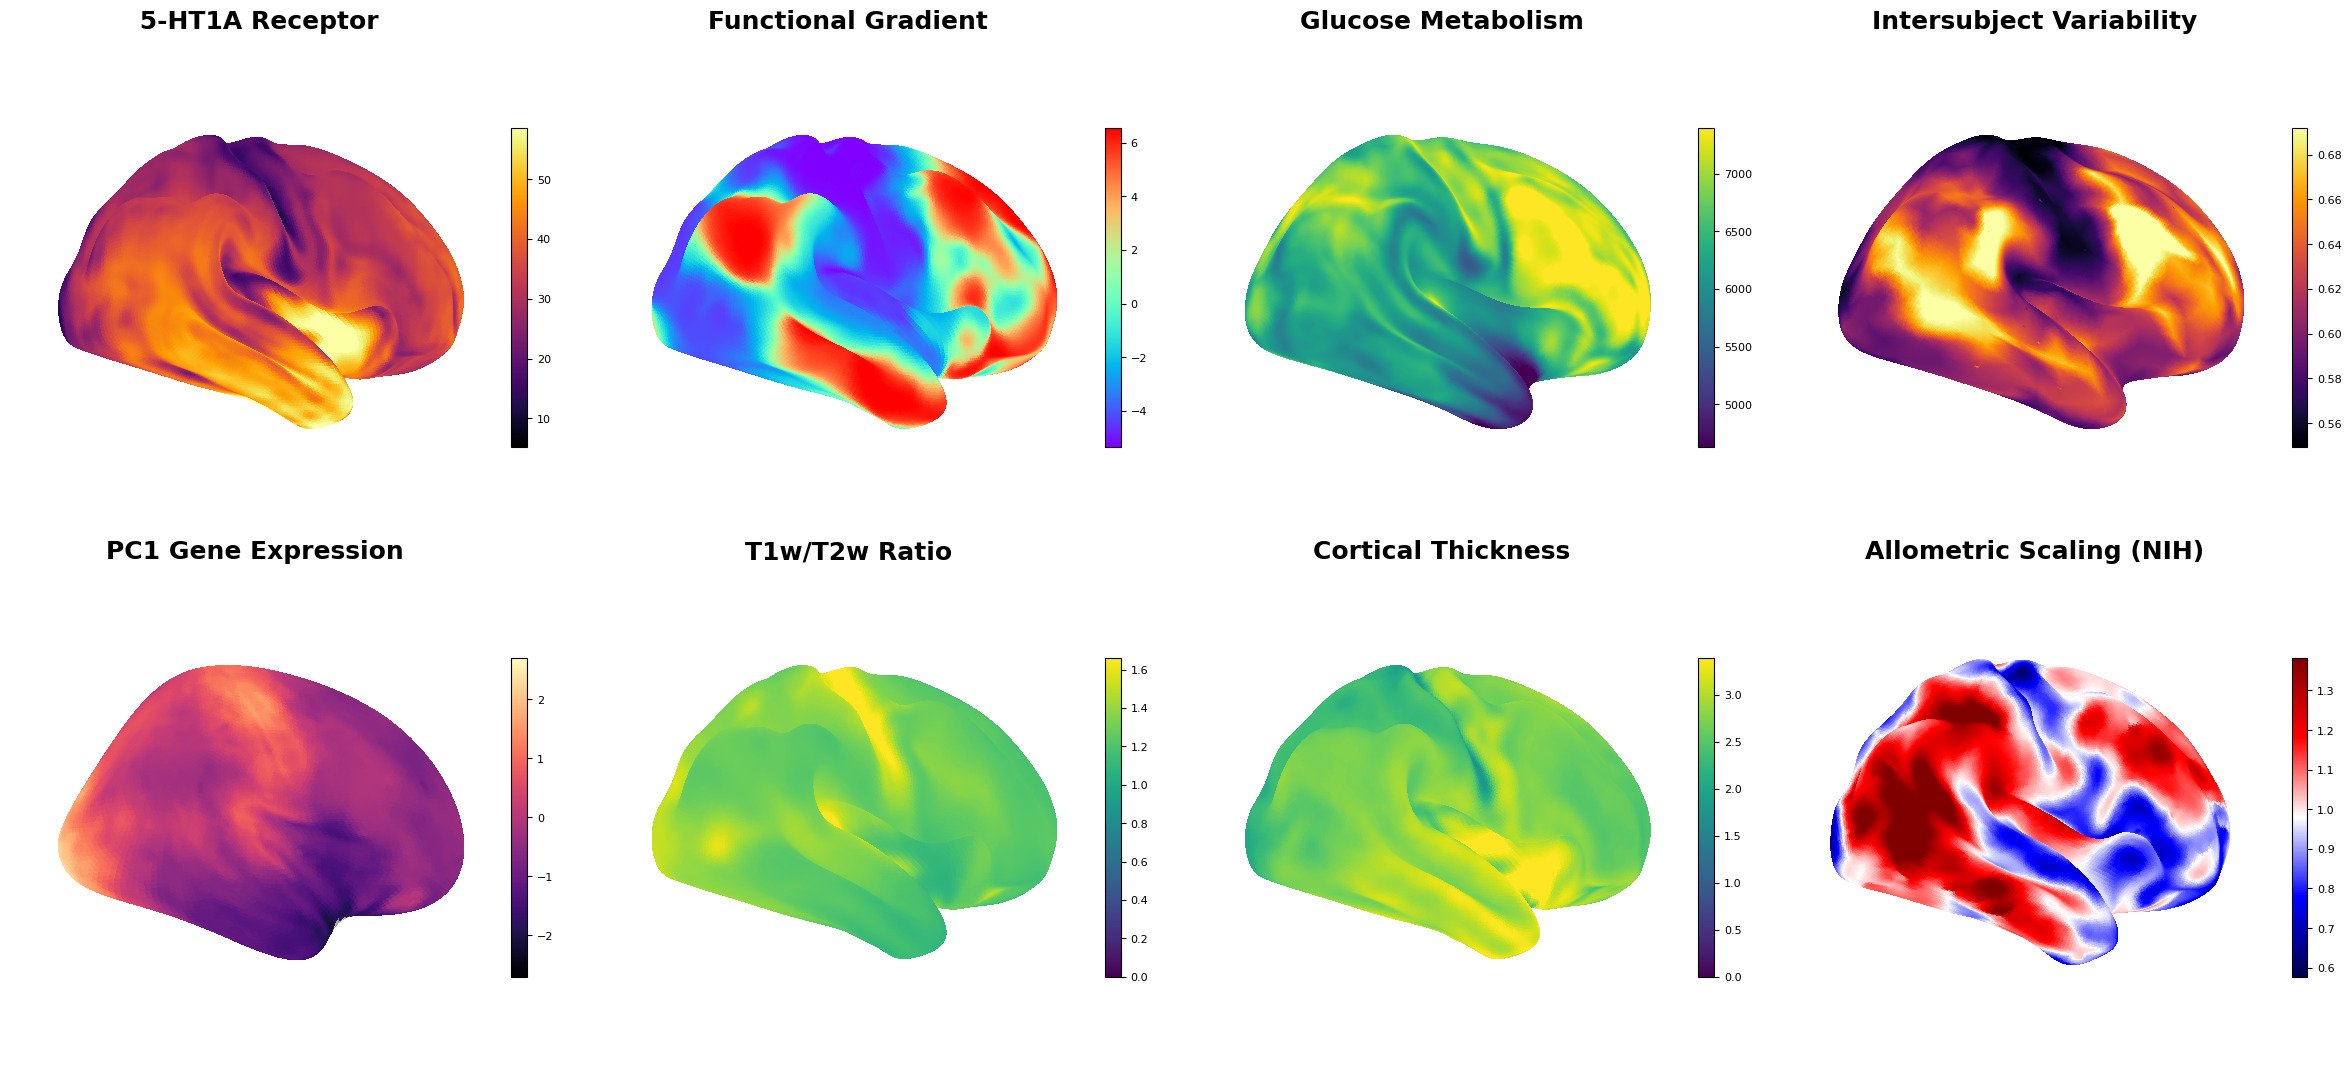

In [29]:
plot_all_brain_maps_subplot(
    brain_maps,
    readable_map_names,
    brain_map_settings
)

PAIRWISE

In [38]:
def get_readable_title(raw_name, name_dict):
    """Converts technical map name to readable title."""
    for key, readable in name_dict.items():
        if key in raw_name:
            return readable
    return raw_name

def generate_coupling_map(map1_data, map2_data, positive=True):
    """
    Generates a "Local Coupling Map" (Rank Difference Map).
    Cubed score highlights strong coupling.
    """
    # Create mask for valid data (remove NaNs and Zeros)
    mask = (~np.isnan(map1_data)) & (~np.isnan(map2_data)) & (map1_data != 0) & (map2_data != 0)
    coupling_map = np.zeros_like(map1_data, dtype=float)
    
    d1 = map1_data[mask]
    d2 = map2_data[mask]

    # Rank 0 to 1
    r1 = rankdata(d1, method='average') / len(d1)
    
    # Logic Switch: Invert r2 if relationship is negative
    if positive:
        r2 = rankdata(d2, method='average') / len(d2)
    else:
        r2 = 1.0 - (rankdata(d2, method='average') / len(d2))
    
    # Calculate similarity
    diff = np.abs(r1 - r2)
    coupling_score = 1.0 - diff
    
    # Cube the score to suppress noise (Mean ~0.66 -> ~0.3)
    coupling_score = coupling_score ** 3
    
    coupling_map[mask] = coupling_score
    return coupling_map

readable_map_names = {
    'genepc1': 'PC1 Gene Expression',
    'myelinmap': 'T1w/T2w Ratio',
    'thickness': 'Cortical Thickness',
    'fcgradient01': 'Functional Gradient',
    'intersubjvar': 'Intersubject Variability',
    'cmrglc': 'Glucose Metabolism',
    'scalingnih': 'Allometric Scaling (NIH)',
    'way100635':' 5-HT1A Receptor'
}

/var/folders/ff/1nvxwnl16fs1my8jhytzdqxw0000gn/T/ipykernel_8474/4000855955.py:55: DeprecationWarning: The `darkness` parameter will be deprecated in release 0.13. We recommend setting `darkness` to None
  plotting.plot_surf(


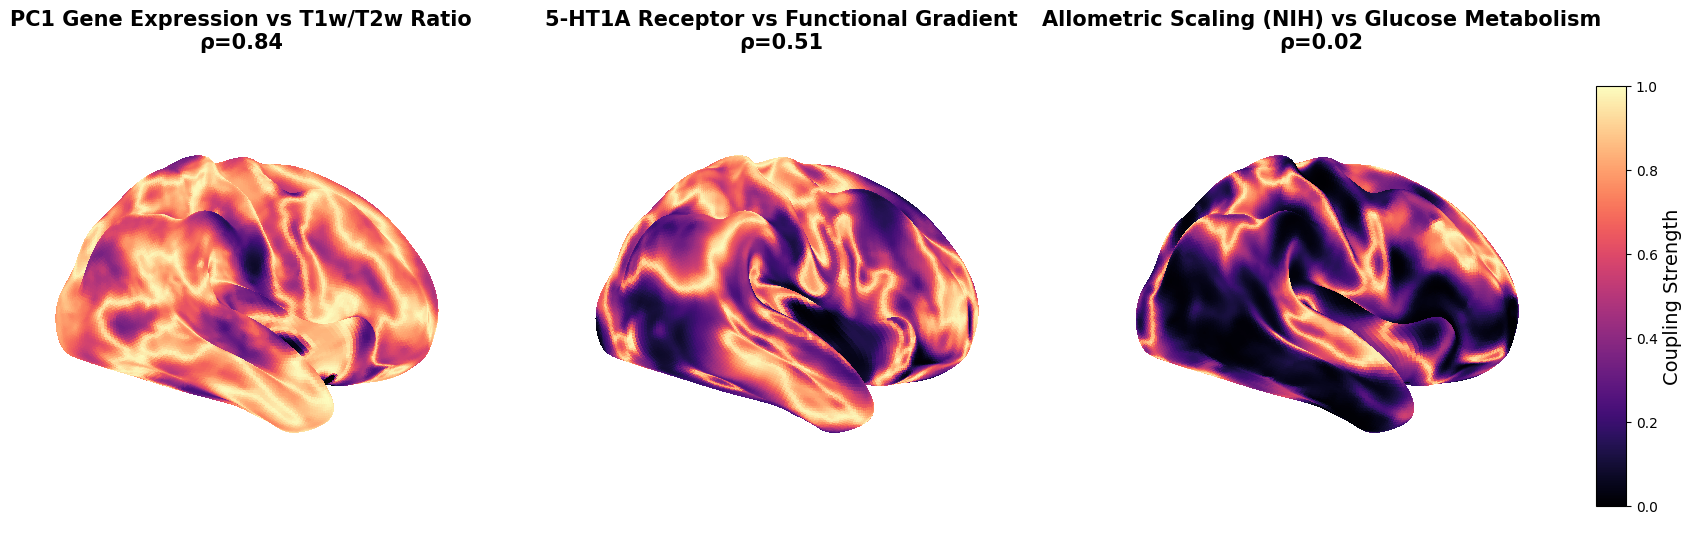

In [42]:
def plot_selected_coupling_pairs_horizontal(map_names,
                                            prepared_maps,
                                            readable_map_names):
    """
    Plots 3 specific coupling pairs (RIGHT hemisphere only)
    in a 1x3 horizontal layout with a properly spaced shared colorbar.
    """
    
    target_desc_pairs = [
        ("genepc1", "myelinmap"),
        ("way100635", "fcgradient01"),
        ("scalingnih", "cmrglc")
    ]
    
    # Build desc → index lookup
    desc_to_index = {
        raw.split('_')[-1]: i
        for i, raw in enumerate(map_names)
    }
    
    fig = plt.figure(figsize=(20, 6))
    
    atlas = fetch_atlas('fsLR', '32k')
    surf_r = atlas['inflated'].R
    
    vmin, vmax = 0, 1
    cmap = 'magma'
    
    axes = []
    
    for col_idx, (desc_a, desc_b) in enumerate(target_desc_pairs):
        
        idx_a = desc_to_index[desc_a]
        idx_b = desc_to_index[desc_b]
        
        data_a = prepared_maps[idx_a]
        data_b = prepared_maps[idx_b]
        
        mask = (~np.isnan(data_a)) & (~np.isnan(data_b)) & (data_a != 0) & (data_b != 0)
        rho, _ = spearmanr(data_a[mask], data_b[mask])
        
        is_positive = rho >= -0.1
        coupling_brain = generate_coupling_map(data_a, data_b, positive=is_positive)
        
        mid = len(coupling_brain) // 2
        data_r = coupling_brain[mid:]
        
        name_a = readable_map_names[desc_a].strip()
        name_b = readable_map_names[desc_b].strip()
        title = f"{name_a} vs {name_b}\nρ={rho:.2f}"
        
        ax = fig.add_subplot(1, 3, col_idx + 1, projection='3d')
        axes.append(ax)
        
        plotting.plot_surf(
            surf_mesh=surf_r,
            surf_map=data_r,
            hemi='right',
            view='lateral',
            cmap=cmap,
            vmin=vmin,
            vmax=vmax,
            colorbar=False,
            axes=ax
        )
        
        ax.set_title(title, fontsize=15, pad=14, fontweight='bold')
    
    # ---- Manually positioned colorbar axis ----
    # [left, bottom, width, height]
    cbar_ax = fig.add_axes([0.92, 0.15, 0.015, 0.7])
    
    sm = plt.cm.ScalarMappable(cmap=cmap)
    sm.set_clim(vmin, vmax)
    cbar = fig.colorbar(sm, cax=cbar_ax)
    cbar.set_label('Coupling Strength', fontsize=14)
    
    # Adjust subplot spacing to make room for colorbar
    plt.subplots_adjust(wspace=0.15, right=0.9)
    
    plt.show()

plot_selected_coupling_pairs_horizontal(
    map_names,
    prepared_maps,
    readable_map_names
)

Ranked Pariwise

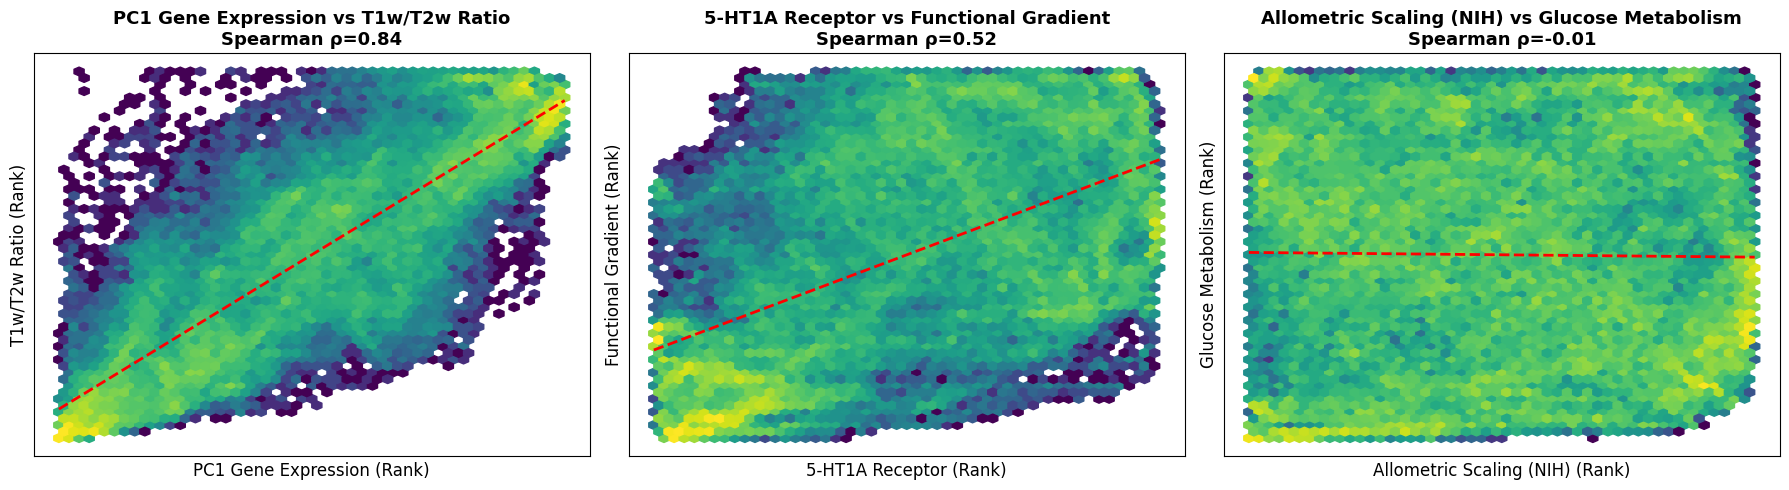

In [44]:
def plot_selected_rank_scatterplots(prepared_maps,
                                    map_names,
                                    readable_map_names):
    """
    Plots only 3 selected rank-based scatterplots
    in a 1x3 horizontal layout.
    """
    
    # Target desc pairs (must match map desc keys)
    target_desc_pairs = [
        ("genepc1", "myelinmap"),
        ("way100635", "fcgradient01"),
        ("scalingnih", "cmrglc")
    ]
    
    # ---- Global Masking ----
    data_stack = np.column_stack(prepared_maps)
    global_mask = np.all((~np.isnan(data_stack)) & (data_stack != 0), axis=1)
    clean_data = data_stack[global_mask]
    
    # ---- Rank transform ----
    ranked_data = np.apply_along_axis(rankdata, 0, clean_data)
    
    # Build desc → index lookup
    desc_to_index = {
        raw.split('_')[-1]: i
        for i, raw in enumerate(map_names)
    }
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    for ax, (desc_a, desc_b) in zip(axes, target_desc_pairs):
        
        idx_a = desc_to_index[desc_a]
        idx_b = desc_to_index[desc_b]
        
        x = ranked_data[:, idx_a]
        y = ranked_data[:, idx_b]
        
        # Spearman via Pearson on ranks
        rho, _ = pearsonr(x, y)
        
        # Hexbin
        ax.hexbin(x, y, gridsize=50, cmap='viridis', mincnt=1, bins='log')
        
        # Trendline
        z = np.polyfit(x, y, 1)
        p = np.poly1d(z)
        x_range = np.linspace(x.min(), x.max(), 100)
        ax.plot(x_range, p(x_range), "r--", linewidth=2)
        
        name_a = readable_map_names[desc_a].strip()
        name_b = readable_map_names[desc_b].strip()
        
        ax.set_title(
            f"{name_a} vs {name_b}\nSpearman ρ={rho:.2f}",
            fontsize=13,
            fontweight='bold'
        )
        
        ax.set_xlabel(f"{name_a} (Rank)", fontsize=12)
        ax.set_ylabel(f"{name_b} (Rank)", fontsize=12)
        
        ax.set_xticks([])
        ax.set_yticks([])
    
    plt.tight_layout()
    plt.show()

plot_selected_rank_scatterplots(
    prepared_maps,
    map_names,
    readable_map_names
)